# Stage 02b — Postprocessing (wizard-driven, 518×518 for DINOv2)

Reads the **02a_preprocessing output** (newest
`Review_postprocess_<batch>_<timestamp>.xlsx` in `paths.html_review_exports`
— flat "Review" sheet, IMGPATH-resolved, Rules A–D applied, approved images
only; falls back to the legacy `reviewed_patents_<batch>.xlsx` in
`paths.wizard_resolved_dir` if 02a hasn't run), takes every **approved**
figure, applies the reviewer's `rotation_deg`, resizes with aspect ratio
preserved and pads to a 518×518 square with a **background-aware fill**
(`src/processor.py:adaptive_pad_resize`):

- the reviewer's `bgSty` label decides solid-vs-reflect when present
  (*Solid Fill* → flat median-colour fill; *Shaded/Gradient* / *Grid/Pattern* → mirror-extend);
- unlabelled images fall back to the border-ring dominant-colour rule.

Outputs (mirror the `matched/` ↔ `data/matched/` convention):

```
processed/<batch>/all/<patent_dir>/<patent>_arch<N>[_main|_2..].png
processed/<batch>/main/<patent>_arch<N>_main.png       flat canonical set (isMain)
data/processed/<batch>/processing_manifest_<batch>.csv the contract with DINOv2_eVTOL_frozen_Analysis
```


In [8]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import pandas as pd
from src.config_loader import load_config
import src.processor as proc

cfg = load_config()
sheet_name  = "Batch_01"          # <- the batch to process
matched_dir = Path(cfg["paths"]["matched"]) / sheet_name

# ── Input: prefer 02a_preprocessing's output ────────────────────────────────
# 02a writes Review_postprocess_<batch>_<timestamp>.xlsx (flat "Review"
# sheet, IMGPATH-resolved, Rules A–D applied, approved images only) into
# html_review_exports ("reviewed xlsxs/"). Pick the newest for this batch;
# fall back to the legacy wizard_resolved_dir convention if 02a hasn't run.
# 02a now writes into cleaned_label_tables/ (2026-08-18) — html_review_exports/ was
# frozen and holds human wizard exports only. Older runs still sitting in the frozen
# folder are picked up too, so nothing already produced becomes unreachable.
exports_dir = Path(cfg["paths"]["cleaned_label_tables"])
exports_dir.mkdir(parents=True, exist_ok=True)
legacy_dir  = Path(cfg["paths"]["html_review_exports"])
candidates = sorted(exports_dir.glob(f"Review_postprocess_{sheet_name}_*.xlsx"))
if not candidates and not (exports_dir / f"Review_postprocess_{sheet_name}.xlsx").exists():
    # Nothing from the new location yet — fall back to whatever the frozen folder still
    # holds for this batch (timestamped runs AND the older non-timestamped files).
    legacy_hits = (sorted(legacy_dir.glob(f"Review_postprocess_{sheet_name}_*.xlsx"))
                   or ([legacy_dir / f"Review_postprocess_{sheet_name}.xlsx"]
                       if (legacy_dir / f"Review_postprocess_{sheet_name}.xlsx").exists() else []))
    if legacy_hits:
        print(f"no 02a output in {exports_dir.name} — using the older run in {legacy_dir.name}")
        exports_dir = legacy_dir
        candidates = sorted(legacy_dir.glob(f"Review_postprocess_{sheet_name}_*.xlsx"))
raw_path = exports_dir / f"Review_postprocess_{sheet_name}.xlsx"
if raw_path.exists():
    REVIEWED_XLSX = raw_path
    print(f"using raw (non-timestamped) 02a output: {raw_path.name}")
elif candidates:
    REVIEWED_XLSX = candidates[-1]   # timestamped names sort chronologically
    print(f"using 02a output ({len(candidates)} run(s) found, newest picked)")
else:
    REVIEWED_XLSX = Path(cfg["paths"]["wizard_resolved_dir"]) / f"reviewed_patents_{sheet_name}.xlsx"
    print("⚠ no 02a output found — falling back to legacy wizard_resolved_dir export")

print(f"batch         : {sheet_name}")
print(f"input export  : {REVIEWED_XLSX}")
print(f"processed out : {Path(cfg['paths']['processed']) / sheet_name}")
print(f"manifest out  : {Path(cfg['paths']['data_processed']) / sheet_name}")
print(f"target_size   : {cfg['processing']['target_size']}   pad mode: {cfg['processing']['pad_color_mode']}")


using raw (non-timestamped) 02a output: Review_postprocess_Batch_01.xlsx
batch         : Batch_01
input export  : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/data/reviewed xlsxs/Review_postprocess_Batch_01.xlsx
processed out : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/processed/Batch_01
manifest out  : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/data/processed/Batch_01
target_size   : [518, 518]   pad mode: auto


---
## Finalize this batch

Run after you've finished human review for this batch in
`UI_for_taxonomy_caracterization_10.0.html`: load `ml_predict_labels_<batch>.xlsx`
via the "Load Batch" xlsx input, review each patent, then click "Export batch"
(or let it auto-export on the last patent). That downloads
`reviewed_patents_<sheet_name>.xlsx` to your browser's download folder
(`cfg["paths"]["html_review_exports"]`, default `~/Downloads`) — the cell below
reads approval status (`T1 → isApproved`) directly from that file, no manual
`batches.xlsx` editing required.

In [9]:
# ── Copy approved files → reviewed/{company}/{prototype}/{patent_id}/ ──────
# Approval status comes from the input export's T1/isApproved field per
# patent (REVIEWED_XLSX from the first cell — 02a's preprocessed output when
# available, so Rule D duplicate-inherited approvals are included).
# company_canonical/prototype_label still come from batches.xlsx, since the
# wizard export doesn't carry that grouping metadata.
import shutil
from pathlib import Path
import pandas as pd
from src.reviewer import resolve_patent_image_dir

if not REVIEWED_XLSX.exists():
    raise FileNotFoundError(
        f"{REVIEWED_XLSX} not found. Run 02a_preprocessing (or export from the "
        f"wizard) first."
    )

review_rows = pd.read_excel(REVIEWED_XLSX, sheet_name="Review")

def _is_true(v):
    if isinstance(v, bool):
        return v
    return str(v).strip().lower() == "true"

approval_rows = review_rows[(review_rows["Section"] == "T1") & (review_rows["Field"] == "isApproved")]
approved_ids = set(
    approval_rows.loc[approval_rows["Value"].apply(_is_true), "Patent_ID"].astype(str)
)
print(f"{len(approved_ids)} patent(s) marked approved in {REVIEWED_XLSX.name}.")

# Exact duplicates (duplicateType "2") never get their own matched/ folder by
# design — they're never independently matched/reviewed; their images live
# under duplicateId's folder instead. Look these up so a missing folder for
# one of them prints as an expected skip, not an unexplained data gap.
_dt_rows = review_rows[review_rows["Field"] == "duplicateType"]
_dup_type_by_pid = _dt_rows.set_index(_dt_rows["Patent_ID"].astype(str))["Value"].map(
    lambda v: str(v).split(" — ")[0].strip() if pd.notna(v) else None)
_did_rows = review_rows[review_rows["Field"] == "duplicateId"]
_dup_id_by_pid = _did_rows.set_index(_did_rows["Patent_ID"].astype(str))["Value"]

batches_path  = cfg["paths"]["batches_xlsx"]
batch_df_live = pd.read_excel(batches_path, sheet_name=sheet_name, dtype=str)
approved = batch_df_live[batch_df_live["patent_id"].astype(str).isin(approved_ids)]
print(f"{len(approved)}/{len(batch_df_live)} patents in {sheet_name} marked approved (via wizard export).")

reviewed_root = Path(cfg["paths"]["reviewed"])
copied, missing, expected_dup = 0, 0, 0
for _, row in approved.iterrows():
    pid       = str(row["patent_id"]).strip()
    company   = str(row["company_canonical"]).strip()
    prototype = str(row["prototype_label"]).strip()
    src_dir   = resolve_patent_image_dir(matched_dir, pid)
    dst_dir   = reviewed_root / company / prototype / pid

    if not src_dir.exists():
        if _dup_type_by_pid.get(pid) == "2":
            dup_of = _dup_id_by_pid.get(pid, "?")
            print(f"  ↪ {pid}: expected — exact duplicate of {dup_of}, no images of its own")
            expected_dup += 1
        else:
            print(f"  ⚠ missing matched/ folder for {pid} — skipped")
            missing += 1
        continue
    dst_dir.parent.mkdir(parents=True, exist_ok=True)
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    shutil.copytree(src_dir, dst_dir)
    copied += 1

print(f"\nCopied: {copied}   Expected (exact duplicate): {expected_dup}   Missing source (needs investigation): {missing}")


292 patent(s) marked approved in Review_postprocess_Batch_01.xlsx.
292/352 patents in Batch_01 marked approved (via wizard export).
  ↪ ITMI20001822A0: expected — exact duplicate of US6220545B1, no images of its own

Copied: 291   Expected (exact duplicate): 1   Missing source (needs investigation): 0


In [10]:
# ── Collect batch outputs → <sheet_name_lower>/ ────────────────────────────
# Copies this batch's xlsx outputs (run_stage01's source_patents_<batch>.xlsx
# and ml_predict_labels_<batch>.xlsx, both written under data_matched/<sheet_name>/
# — there are no per-patent label JSONs in the current pipeline, see
# reviewer.py's module docstring) + any review HTML exports into a flat
# top-level folder for your own validation/inspection. Purely a convenience
# snapshot — skip once you trust the pipeline and are running all batches
# end-to-end without spot-checking each one individually.
import shutil
from pathlib import Path

BATCH_OUT = Path(cfg["paths"]["base"]) / sheet_name.lower()
BATCH_OUT.mkdir(parents=True, exist_ok=True)

# 1. per-batch xlsx outputs written by run_stage01()
batch_data_dir = Path(cfg["paths"]["data_matched"]) / sheet_name
n_xlsx = 0
for f in batch_data_dir.glob("*.xlsx"):
    shutil.copy2(f, BATCH_OUT / f.name)
    n_xlsx += 1

# 2. review HTML exports for this batch, if any were generated
html_src = Path(cfg["paths"]["data"]) / "review_html" / sheet_name
html_dst = BATCH_OUT / "review_html"
n_html = 0
if html_src.exists():
    shutil.copytree(html_src, html_dst, dirs_exist_ok=True)
    n_html = len(list(html_dst.glob("*")))

print(f"Collected {n_xlsx} xlsx file(s) and {n_html} HTML file(s) → {BATCH_OUT}")


Collected 1 xlsx file(s) and 0 HTML file(s) → /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/batch_01


---
## Run Stage 02

Pre-flight first (does the export exist, how many approved images, any missing
files), then `process_batch` writes `all/`, `main/` and the manifest.


In [11]:
# ── Pre-flight: what will be processed? ─────────────────────────────────────
images = proc.load_review_images(REVIEWED_XLSX)
images["file_exists"] = images["Image_Path"].map(lambda p: Path(str(p)).exists())

n_missing = int((images["approved"] & ~images["file_exists"]).sum())
print(f"{len(images)} images in export | approved: {int(images['approved'].sum())} "
      f"(mains: {int((images['approved'] & images['is_main']).sum())}) | "
      f"rotated: {int((images['approved'] & images['rotation'].ne(0)).sum())}")
if n_missing:
    print(f"⚠ {n_missing} approved images MISSING on disk — did you run "
          f"scripts/resolve_image_paths.py on the export?")
    display(images.loc[images['approved'] & ~images['file_exists'], 'Image_Path'])
display(images.loc[images["approved"], ["bgSty", "bgCol", "acCol"]]
        .apply(lambda s: s.value_counts(dropna=False)).fillna(0).astype(int))


300 images in export | approved: 300 (mains: 150) | rotated: 12


,bgSty,bgCol,acCol
B/W (Monochrome),0,0,298
Grayscale,0,0,2
Solid Fill,300,0,0
White,0,300,0


In [12]:
# ── Process the batch ───────────────────────────────────────────────────────
# reviewed_xlsx=REVIEWED_XLSX so it consumes 02a's preprocessed output (or
# the legacy file, whichever the first cell resolved). force=True to reprocess.
manifest = proc.process_batch(sheet_name, cfg, reviewed_xlsx=REVIEWED_XLSX)


[process_batch] Batch_01: 300/300 images processed (150 mains) -> /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/processed/Batch_01
  manifest: /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/data/processed/Batch_01/processing_manifest_Batch_01.csv


In [13]:
# ── QC: fill decisions, seams, label agreement ──────────────────────────────
done = manifest[manifest["processed"]]

print("fill methods:", dict(done["fill_method"].value_counts()))
print("skip reasons:", dict(manifest.loc[~manifest["processed"], "skip_reason"].value_counts()))
print("\nseam std (0 = perfectly flat border after padding):")
display(done["seam_std"].describe().round(2).to_frame().T)

mismatch = done[done["fill_vs_label_ok"] == False]  # noqa: E712 — NaN-safe
if len(mismatch):
    print(f"⚠ {len(mismatch)} images where the painted fill disagrees with the bgCol label:")
    display(mismatch[["patent_id", "fig_key", "bg_col", "fill_color_hex",
                      "dominant_frac", "src_path"]])
else:
    print("✓ every painted fill agrees with its bgCol label")

print("\n10 worst seams (eyeball these):")
display(done.nlargest(10, "seam_std")[["patent_id", "fig_key", "fill_method",
                                       "fill_color_hex", "seam_std", "dst_all"]])


fill methods: {'solid': 300}
skip reasons: {}

seam std (0 = perfectly flat border after padding):


,count,mean,std,min,25%,50%,75%,max
seam_std,300.0,2.63,5.91,0.0,0.0,0.0,1.64,38.21


✓ every painted fill agrees with its bgCol label

10 worst seams (eyeball these):


,patent_id,fig_key,fill_method,fill_color_hex,seam_std,dst_all
291,US6220545B1,1A,solid,#ffffff,38.21,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
11,CN113525678A,210913100419_crop_0_Fu,solid,#ffffff,32.52,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
180,US2020391861A1,Fu_D00000,solid,#ffffff,30.36,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
182,US2020391861A1,2,solid,#ffffff,30.36,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
5,CN106585976A,CN106585976A_HDA0001166873360000021_crop_0_Fu,solid,#ffffff,27.49,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
288,US2023331380A1,1B,solid,#ffffff,27.36,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
135,US2019329898A1,NaN,solid,#ffffff,23.17,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
199,US2021094674A1,1,solid,#ffffff,20.08,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
268,US2023033507A1,NaN,solid,#ffffff,18.98,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...
60,US2016207625A1,NaN,solid,#ffffff,18.58,/mnt/storage_11tb/Drive_files_to_syncronize/3 ...


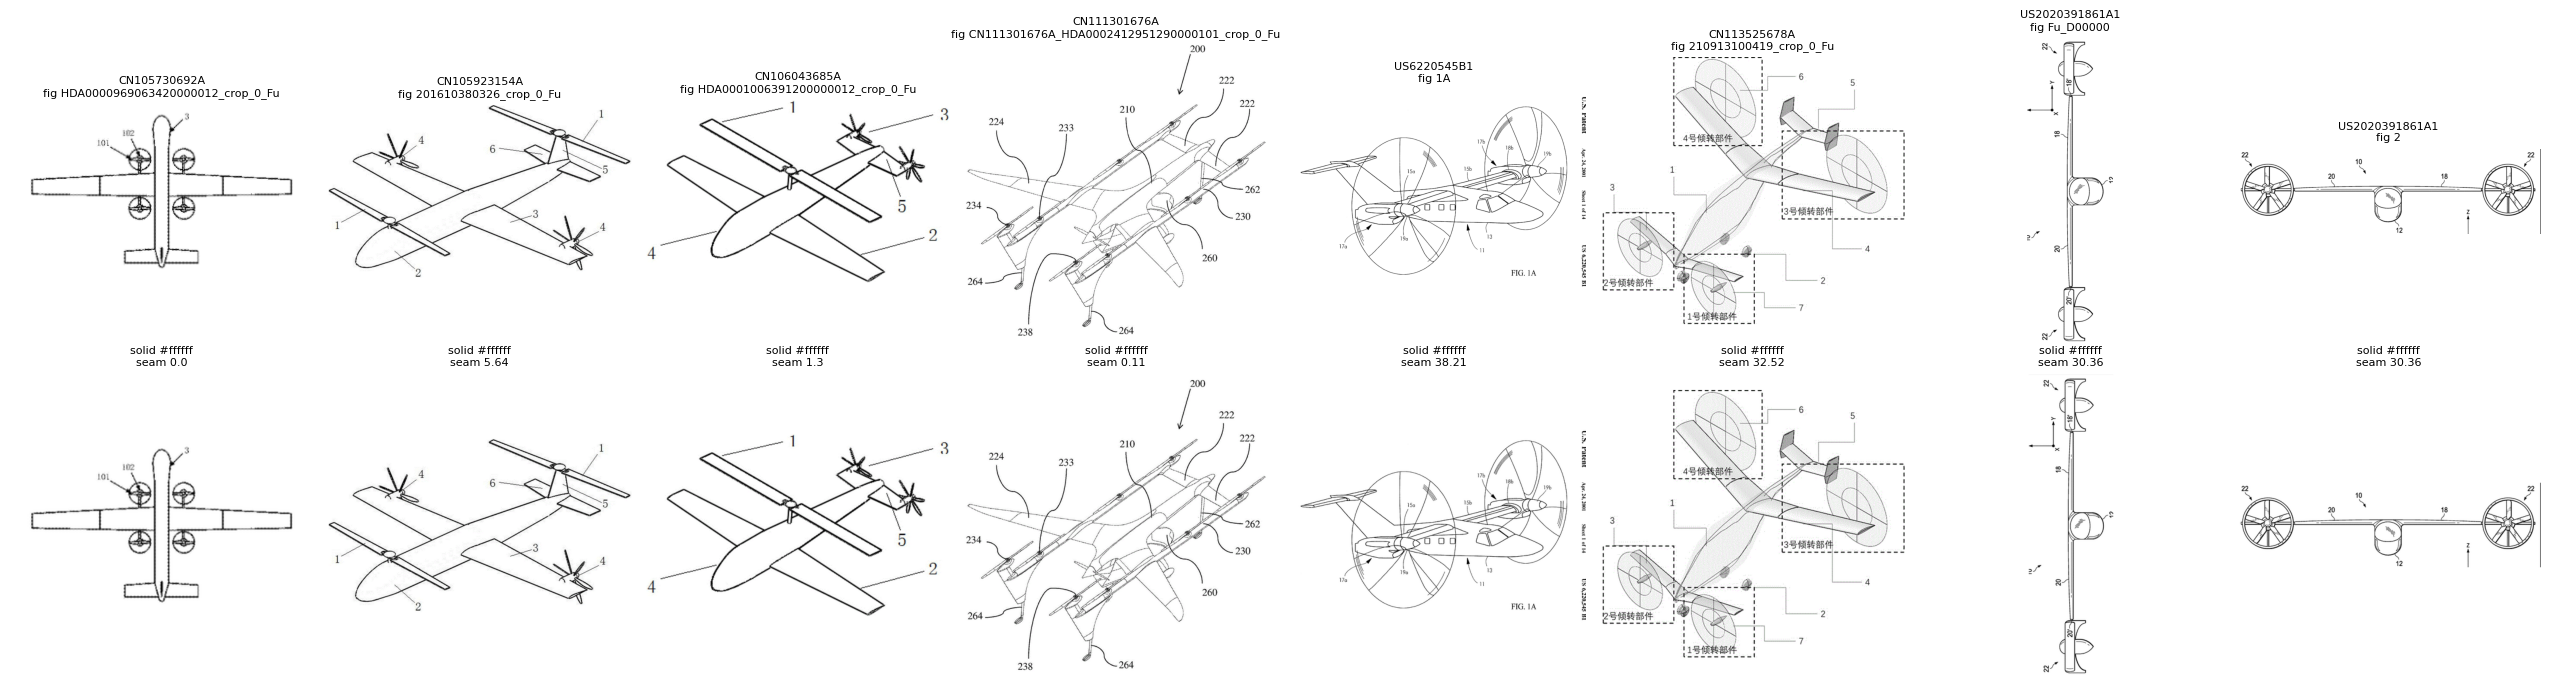

In [14]:
# ── Visual check: original vs processed (mains first, then worst seams) ─────
import matplotlib.pyplot as plt
from PIL import Image

show = pd.concat([done[done["is_main"]].head(4),
                  done.nlargest(4, "seam_std")]).drop_duplicates("src_path")
fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 7))
for j, (_, r) in enumerate(show.iterrows()):
    axes[0, j].imshow(Image.open(r["src_path"]))
    axes[0, j].set_title(f"{r['base_patent_id']}\nfig {r['fig_key']}", fontsize=8)
    axes[1, j].imshow(Image.open(r["dst_all"]))
    axes[1, j].set_title(f"{r['fill_method']} {r['fill_color_hex']}\nseam {r['seam_std']}", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("processed 518²")
plt.tight_layout(); plt.show()
